# SK Hynix Defect Test Prediction (난이도 下)
FDC Trace → C65 (Defect Test) 회귀 예측 | 평가: RMSE

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '문제1(하)/'
ANS_DIR  = '문제1_하_answer/'

## 1. 데이터 로드

In [2]:
train = pd.read_csv(DATA_DIR + 'train_data.csv')
valid_X = pd.read_csv(DATA_DIR + 'valid_X.csv')
test_X  = pd.read_csv(DATA_DIR + 'test_X.csv')

valid_Y_prob = pd.read_csv(DATA_DIR + 'valid_Y_problem.csv')
test_Y_prob  = pd.read_csv(DATA_DIR + 'test_Y_problem.csv')

valid_Y_ans = pd.read_csv(ANS_DIR + 'valid_Y_answer.csv')
test_Y_ans  = pd.read_csv(ANS_DIR + 'test_Y_answer.csv')

print(f"train: {train.shape}, valid_X: {valid_X.shape}, test_X: {test_X.shape}")
print(f"train WFs: {train.C64.nunique()}, valid WFs: {valid_X.C64.nunique()}, test WFs: {test_X.C64.nunique()}")

train: (123614, 65), valid_X: (20577, 64), test_X: (20510, 64)
train WFs: 11939, valid WFs: 1990, test WFs: 1990


## 2. 전처리 — 컬럼 정렬, 불필요 컬럼 제거

In [3]:
# --- 컬럼 역할 정의 ---
WF_ID   = 'C64'
TARGET  = 'C65'

# 제거 대상
DROP_IDS      = ['C34', 'C35', 'C38']           # 중복 WF ID
DROP_LOT_IDS  = ['C20', 'C21', 'C22']           # Lot ID — 일반화 불가
DROP_CONST    = ['C14', 'C24']                   # 상수 컬럼
DROP_EXCLUDE  = ['C26', 'C28', 'C29', 'C37']    # 명세상 제외
DROP_ALLNA    = ['C2', 'C13', 'C43', 'C47', 'C53', 'C55']  # 전부 결측
DROP_TIME_RAW = ['C10', 'C39', 'C40']           # 절대시간 (파생 후 제거)

DROP_ALL = DROP_IDS + DROP_LOT_IDS + DROP_CONST + DROP_EXCLUDE + DROP_ALLNA + DROP_TIME_RAW

# valid/test 컬럼을 train 순서에 맞춤
train_cols_no_target = [c for c in train.columns if c != TARGET]
valid_X = valid_X[train_cols_no_target]
test_X  = test_X[train_cols_no_target]

print("컬럼 정렬 완료. train_cols (Y제외):", len(train_cols_no_target))
print("제거 예정 컬럼 수:", len(DROP_ALL))

컬럼 정렬 완료. train_cols (Y제외): 64
제거 예정 컬럼 수: 21


## 3. Feature Engineering — WF 단위 시계열 집계

In [6]:
def compute_slope(series):
    """시계열의 선형 기울기 (step 진행에 따른 추세)"""
    y = series.dropna().values
    if len(y) < 2:
        return 0.0
    x = np.arange(len(y), dtype=np.float64)
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope

def extract_wf_features(df, has_target=True):
    """
    WF(C64) 단위로 row-level 시계열을 집계하여 1 WF = 1 row 피처 생성.
    물리적 의미가 있는 FDC 센서 + 공정 조건만 사용.
    """
    # 사용할 수치형 FDC 센서 컬럼 식별
    meta_cols = [WF_ID] + DROP_ALL + ([TARGET] if has_target else [])
    cat_cols  = ['C6', 'C7']  # recipe, step — 별도 처리
    time_col  = 'C41'         # step 내 경과시간
    pm_col    = 'C33'         # PM time

    all_exclude = set(meta_cols + cat_cols)
    numeric_cols = [c for c in df.select_dtypes(include=[np.number]).columns
                    if c not in all_exclude]

    groups = df.groupby(WF_ID)

    # --- 수치형 FDC 센서 집계 ---
    agg_funcs = {
        c: ['mean', 'std', 'min', 'max', 'median']
        for c in numeric_cols
    }
    agg_df = groups.agg(agg_funcs)
    agg_df.columns = [f"{c}_{fn}" for c, fn in agg_df.columns]

    # range, last-first(변화량)
    range_df = groups[numeric_cols].apply(lambda x: x.max() - x.min())
    range_df.columns = [f"{c}_range" for c in numeric_cols]

    delta_df = groups[numeric_cols].apply(lambda x: x.iloc[-1] - x.iloc[0])
    delta_df.columns = [f"{c}_delta" for c in numeric_cols]

    # slope (추세)
    slope_df = groups[numeric_cols].apply(lambda x: x.apply(compute_slope))
    slope_df.columns = [f"{c}_slope" for c in numeric_cols]

    # --- step 수, 총 소요시간 ---
    meta_df = pd.DataFrame(index=groups.groups.keys())
    meta_df['n_rows'] = groups.size()
    meta_df['C41_total'] = groups[time_col].max()

    # --- PM time (C33) 대표값 ---
    meta_df['C33_first'] = groups[pm_col].first()
    meta_df['C33_max']   = groups[pm_col].max()

        # --- 범주형: Recipe(C6) one-hot 비율, Step(C7) 분포 ---
    if 'C6' in df.columns:
        c6_dummies = pd.get_dummies(df[[WF_ID, 'C6']].set_index(WF_ID)['C6'], prefix='C6')
        c6_feat = c6_dummies.groupby(level=0).mean()
    else:
        c6_feat = pd.DataFrame(index=groups.groups.keys())

    if 'C7' in df.columns:
        c7_dummies = pd.get_dummies(df[[WF_ID, 'C7']].astype(str).set_index(WF_ID)['C7'], prefix='C7')
        c7_feat = c7_dummies.groupby(level=0).mean()
    else:
        c7_feat = pd.DataFrame(index=groups.groups.keys())

    # --- 결합 ---
    features = pd.concat([agg_df, range_df, delta_df, slope_df, meta_df, c6_feat, c7_feat], axis=1)
    features.index.name = WF_ID
    features = features.reset_index()

    # --- 타깃 (있으면) ---
    if has_target:
        target_df = groups[TARGET].first().reset_index()
        features = features.merge(target_df, on=WF_ID)

    return features

print("Feature engineering 함수 정의 완료")

Feature engineering 함수 정의 완료


In [7]:
%%time
print("Train 피처 추출 중...")
train_feat = extract_wf_features(train, has_target=True)
print(f"  → {train_feat.shape}")

print("Valid 피처 추출 중...")
valid_feat = extract_wf_features(valid_X, has_target=False)
print(f"  → {valid_feat.shape}")

print("Test 피처 추출 중...")
test_feat = extract_wf_features(test_X, has_target=False)
print(f"  → {test_feat.shape}")

Train 피처 추출 중...
  → (11939, 317)
Valid 피처 추출 중...
  → (1990, 316)
Test 피처 추출 중...
  → (1990, 316)
CPU times: total: 4min 57s
Wall time: 5min 1s


## 4. 피처/타깃 분리 & 피처 컬럼 정렬

In [8]:
feature_cols = [c for c in train_feat.columns if c not in [WF_ID, TARGET]]

# train/valid/test에 공통으로 존재하는 피처만 사용
common_cols = sorted(set(feature_cols) & set(valid_feat.columns) & set(test_feat.columns))
print(f"공통 피처 수: {len(common_cols)}")

X_train = train_feat[common_cols].values
y_train = train_feat[TARGET].values
wf_train = train_feat[WF_ID].values

X_valid = valid_feat[common_cols].values
X_test  = test_feat[common_cols].values

wf_valid = valid_feat[WF_ID].values
wf_test  = test_feat[WF_ID].values

# 정답 (평가용)
valid_answer = valid_Y_ans.set_index('C64').loc[wf_valid, 'C65'].values
test_answer  = test_Y_ans.set_index('C64').loc[wf_test, 'C65'].values

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_valid: {X_valid.shape}, X_test: {X_test.shape}")

# 베이스라인: 타깃 평균 예측
baseline_rmse = np.sqrt(mean_squared_error(valid_answer, np.full_like(valid_answer, y_train.mean())))
print(f"\n베이스라인 RMSE (평균 예측): {baseline_rmse:.2f}")

공통 피처 수: 314
X_train: (11939, 315), y_train: (11939,)
X_valid: (1990, 315), X_test: (1990, 315)

베이스라인 RMSE (평균 예측): 258.97


## 5. GroupKFold CV + LightGBM 학습

In [9]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'max_depth': -1,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 1.0,
    'n_estimators': 2000,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1,
}

N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

# WF ID를 정수 그룹으로 매핑
wf_to_int = {wf: i for i, wf in enumerate(np.unique(wf_train))}
groups = np.array([wf_to_int[wf] for wf in wf_train])

oof_preds = np.zeros(len(X_train))
valid_preds_folds = np.zeros(len(X_valid))
test_preds_folds  = np.zeros(len(X_test))
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups)):
    X_tr, X_val = X_train[tr_idx], X_train[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(0),
        ]
    )

    oof_preds[val_idx] = model.predict(X_val)
    valid_preds_folds += model.predict(X_valid) / N_FOLDS
    test_preds_folds  += model.predict(X_test) / N_FOLDS

    fold_rmse = np.sqrt(mean_squared_error(y_val, oof_preds[val_idx]))
    fold_scores.append(fold_rmse)
    print(f"Fold {fold+1}: RMSE={fold_rmse:.4f}, best_iter={model.best_iteration_}")

oof_rmse = np.sqrt(mean_squared_error(y_train, oof_preds))
print(f"\nOOF RMSE (CV): {oof_rmse:.4f} ± {np.std(fold_scores):.4f}")

Fold 1: RMSE=62.7891, best_iter=164
Fold 2: RMSE=62.6444, best_iter=100
Fold 3: RMSE=62.4447, best_iter=98
Fold 4: RMSE=62.8441, best_iter=90
Fold 5: RMSE=63.6515, best_iter=118

OOF RMSE (CV): 62.8761 ± 0.4122


## 6. Valid / Test RMSE 평가

In [11]:
valid_rmse = np.sqrt(mean_squared_error(valid_answer, valid_preds_folds))
test_rmse  = np.sqrt(mean_squared_error(test_answer, test_preds_folds))

print("=" * 50)
print(f"베이스라인 (평균)   RMSE : {baseline_rmse:.4f}")
print(f"CV OOF              RMSE : {oof_rmse:.4f}")
print(f"Valid (리더보드)    RMSE : {valid_rmse:.4f}")
print(f"Test  (최종)        RMSE : {test_rmse:.4f}")
print("=" * 50)

gap = abs(oof_rmse - valid_rmse)
print(f"\nCV↔Valid 격차: {gap:.4f}", "✓ 안정적" if gap < 30 else "⚠ 과적합 의심")

베이스라인 (평균)   RMSE : 258.9707
CV OOF              RMSE : 62.8761
Valid (리더보드)    RMSE : 62.5250
Test  (최종)        RMSE : 61.1482

CV↔Valid 격차: 0.3510 ✓ 안정적


## 7. Feature Importance 확인

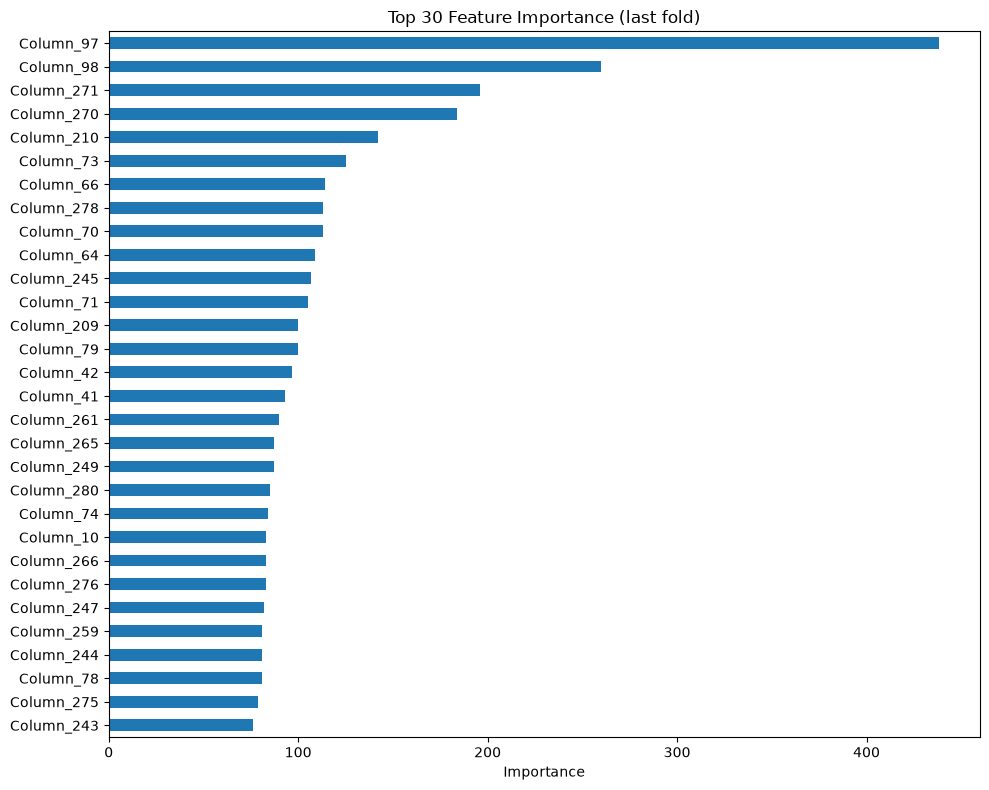

In [13]:
import matplotlib.pyplot as plt

imp = pd.Series(model.feature_importances_, index=model.feature_name_)
top30 = imp.nlargest(30)

fig, ax = plt.subplots(figsize=(10, 8))
top30.sort_values().plot.barh(ax=ax)
ax.set_title('Top 30 Feature Importance (last fold)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 8. 제출 파일 생성

In [14]:
# Valid 제출
valid_submit = valid_Y_prob.copy()
wf_to_pred_v = dict(zip(wf_valid, valid_preds_folds))
valid_submit['C65'] = valid_submit['C64'].map(wf_to_pred_v)
valid_submit.to_csv('valid_Y_submit.csv', index=False)

# Test 제출
test_submit = test_Y_prob.copy()
wf_to_pred_t = dict(zip(wf_test, test_preds_folds))
test_submit['C65'] = test_submit['C64'].map(wf_to_pred_t)
test_submit.to_csv('test_Y_submit.csv', index=False)

print("제출 파일 저장 완료:")
print(f"  valid_Y_submit.csv — {valid_submit.shape}")
print(f"  test_Y_submit.csv  — {test_submit.shape}")
print()
print(valid_submit.head())
print(test_submit.head())

제출 파일 저장 완료:
  valid_Y_submit.csv — (1990, 2)
  test_Y_submit.csv  — (1990, 2)

         C64          C65
0    C64_100   683.809020
1   C64_1012   679.051950
2  C64_10151  1534.944911
3  C64_10155  1504.400714
4  C64_10181  1439.900472
         C64          C65
0      C64_0   676.556629
1  C64_10150  1524.657311
2  C64_10174  1466.136465
3  C64_10178  1481.318560
4   C64_1018   670.550649


## 9. 일반화 점검 — 예측 분포 vs 실제 분포

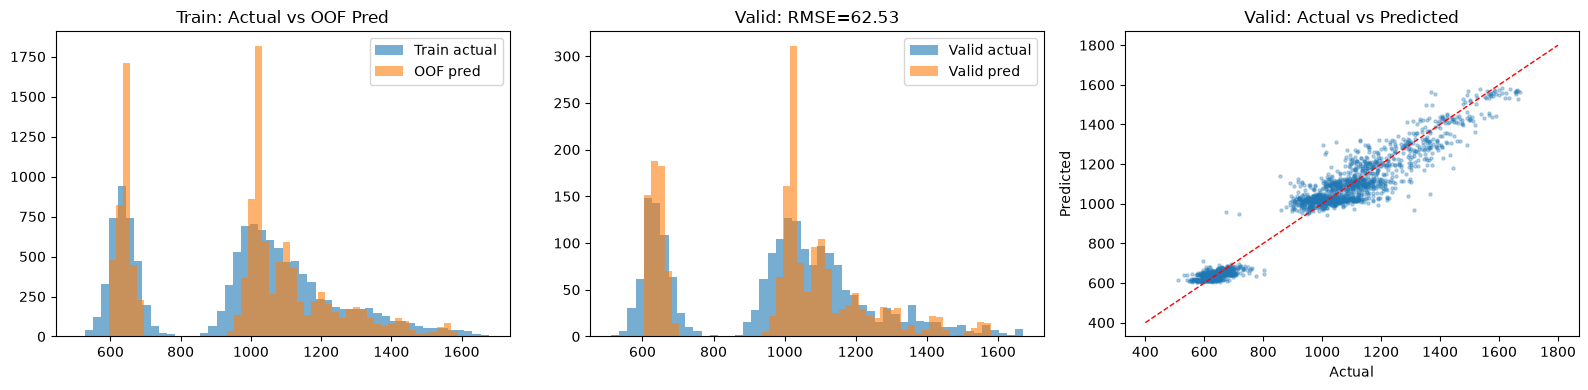

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(y_train, bins=50, alpha=0.6, label='Train actual')
axes[0].hist(oof_preds, bins=50, alpha=0.6, label='OOF pred')
axes[0].set_title('Train: Actual vs OOF Pred')
axes[0].legend()

axes[1].hist(valid_answer, bins=50, alpha=0.6, label='Valid actual')
axes[1].hist(valid_preds_folds, bins=50, alpha=0.6, label='Valid pred')
axes[1].set_title(f'Valid: RMSE={valid_rmse:.2f}')
axes[1].legend()

axes[2].scatter(valid_answer, valid_preds_folds, s=5, alpha=0.3)
axes[2].plot([400, 1800], [400, 1800], 'r--', lw=1)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title('Valid: Actual vs Predicted')

plt.tight_layout()
plt.show()